In [1]:
from trajectories import *
from jax_signatures.signature import * 
from jax_signatures.exact_representations import * 
from jax_signatures.ode_solver import * 
from schemes import * 
from utils import *
from fourier import *
from fourier_sig import * 

from matplotlib.ticker import FuncFormatter
import time 

## 0. Black-Scholes model (sanity check)

In [91]:
T = 4
T0 = -4
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
M, d = 5, 2 
shuffle_table = get_shuffle_table(M=M, d=d)
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=3)
S0 = 1 

In [92]:
sigma_BS, rho = 0.3, 0.0 
l = Tensor(array=jnp.zeros(number_of_words(M, d)).at[0].set(sigma_BS), M=M, d=d)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 

u = jnp.linspace(0, 10, 100)
u_grid = u * 1j

lambd = jnp.array([5.0, 5.0])

psi_T = solve_Riccati_EFM_vol(u_grid, v_grid, l, lambd, rho, shuffle_table, t_main, M, d)

W0 = EFM_sig[:, 0, 0].astype(jnp.complex128)
phi = jnp.exp(psi_T[:, 0, :] @ W0)

phi_exact = jnp.exp((u_grid**2 - u_grid) / 2 * sigma_BS**2 * T)

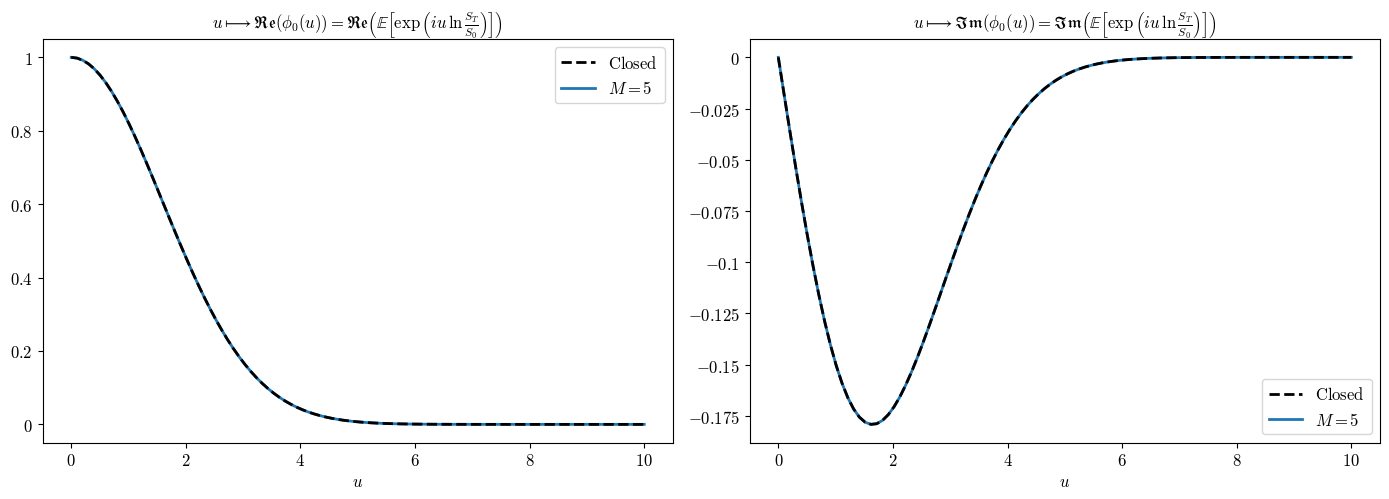

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.1))

ax[0].plot(u, phi_exact.real, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[0].plot(u, phi.real, zorder=0, lw=2, label=fr"$M={M}$")
ax[0].set_title(r"$u\longmapsto\mathfrak{Re}(\phi_0(u))= \mathfrak{Re}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[1].plot(u, phi_exact.imag, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[1].plot(u, phi.imag, zorder=0, lw=2, color="tab:blue", label=fr"$M={M}$")
ax[1].set_title(r"$u\longmapsto\mathfrak{Im}(\phi_0(u)) = \mathfrak{Im}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

for i in range(2) : 
    ax[i].legend(fontsize=12)
    ax[i].set_xlabel(r"$u$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

plt.tight_layout()
plt.show()

## I. Stein Stein model 

In [2]:
T = 1
T0 = -4
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
M, d = 5, 2 
shuffle_table = get_shuffle_table(M=M, d=d)
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=3)
S0 = 1 

### I.1. Signature representation and characteristic function 

In [3]:
lambd_1 = jnp.array([2.0, 2.0])
mu_1, theta_1, eta_1, rho_1 = 2, 1.0, 1.5, -0.7
lambd_2 = jnp.array([5.0, 5.0])
mu_2, theta_2, eta_2, rho_2 = 5, 1.0, 1.5, -0.7


l_EFM_1 = compute_l_EFM_OU(lambd_1, mu_1, theta_1, eta_1, M, x=theta_1)
EFM_sig_1 = compute_EFM_signature(paths, t_grid, lambd_1, M)
l_EFM_2 = compute_l_EFM_OU(lambd_2, mu_2, theta_2, eta_2, M, x=theta_2)
EFM_sig_2 = compute_EFM_signature(paths, t_grid, lambd_2, M)

X_true_1 = simulate_Langevin_Euler(theta_1, mu_1, theta_1, eta_1, paths)
x_1 = X_true_1[0, len(t_burn)]
X_true_2 = simulate_Langevin_Euler(theta_2, mu_2, theta_2, eta_2, paths)
x_2 = X_true_2[0, len(t_burn)]

l_1 = compute_l_OU(x_1, mu_1, theta_1, eta_1, M, d, shuffle_table)
sig_1 = compute_signature(paths[:, len(t_burn):, :], M)
l_2 = compute_l_OU(x_2, mu_2, theta_2, eta_2, M, d, shuffle_table)
sig_2 = compute_signature(paths[:, len(t_burn):, :], M)

Z = np.diff(paths[:, len(t_burn):, 1]) / np.sqrt(t_main[-1] - t_main[-2])
Z2 = np.zeros((1, len(t_main), 2))
Z2[:, 1:, 0] = Z

_, X_exact_1 = simulate_SteinStein(1, len(t_main)-1, T, S0, x_1, mu_1, theta_1, eta_1, rho_1, Z2)
_, X_exact_2 = simulate_SteinStein(1, len(t_main)-1, T, S0, x_2, mu_2, theta_2, eta_2, rho_2, Z2)

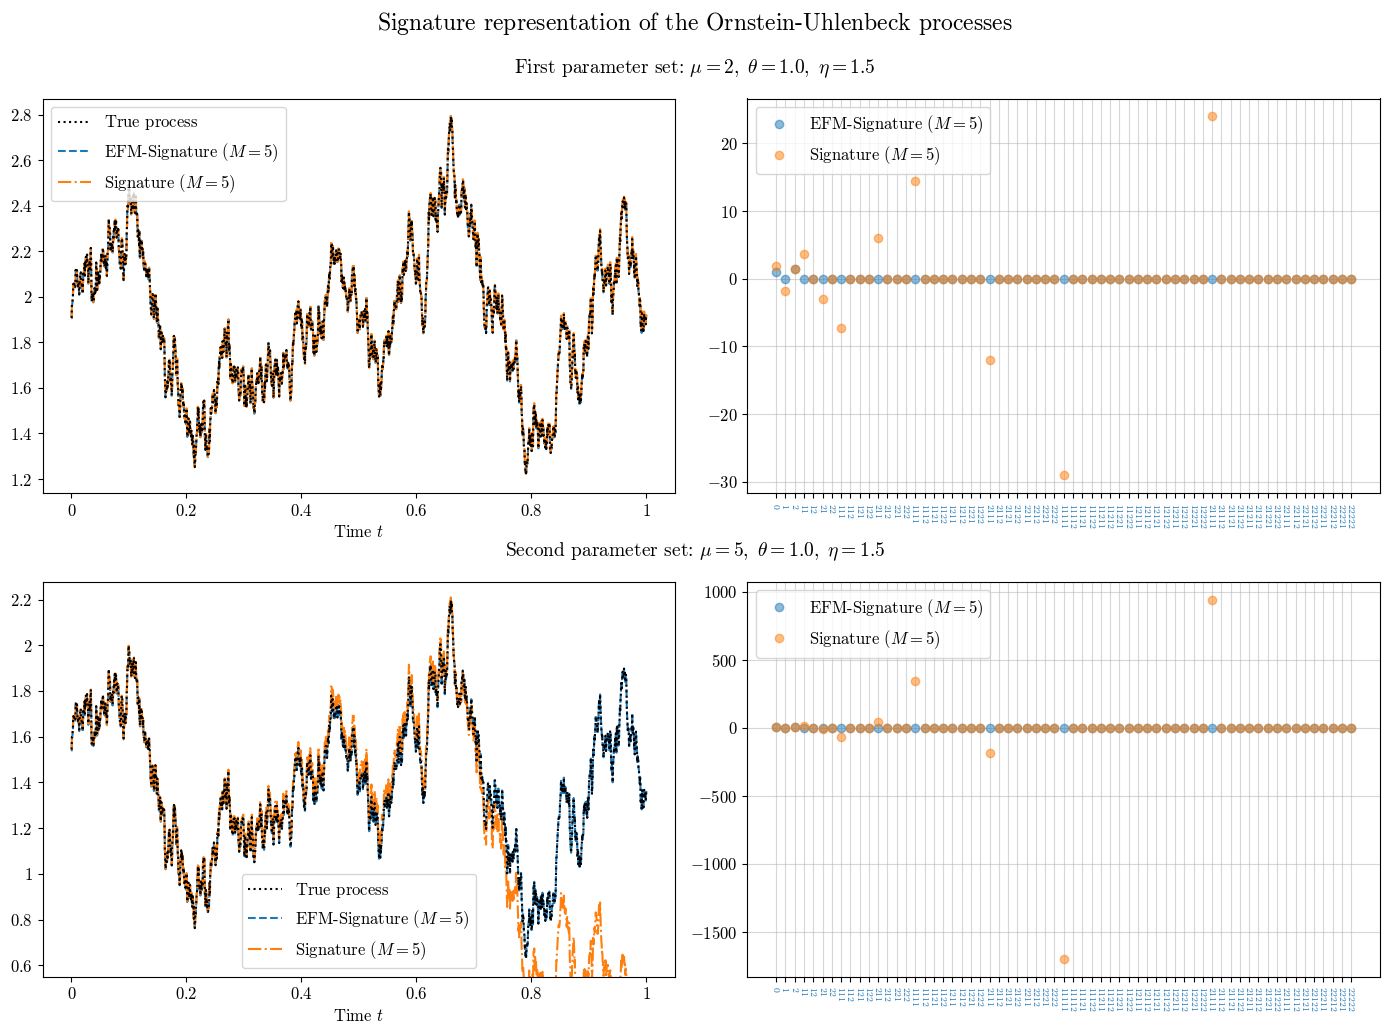

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))
ax = ax.flatten() 

ax[0].plot(t_main, X_true_1[0, len(t_burn):], color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[0].plot(t_main, (EFM_sig_1 @ l_EFM_1).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[0].get_ylim()
ax[0].plot(t_main, (sig_1 @ l_1).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].set_ylim(lims)

l_EFM_1.plot(ax=ax[1], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_1.plot(ax=ax[1], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

ax[2].plot(t_main, X_true_2[0, len(t_burn):], color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[2].plot(t_main, (EFM_sig_2 @ l_EFM_2).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[2].get_ylim()
ax[2].plot(t_main, (sig_2 @ l_2).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].set_ylim(lims)

l_EFM_2.plot(ax=ax[3], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_2.plot(ax=ax[3], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

for i in [0, 2] :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(fontsize=12)


fig.suptitle(r"$\text{Signature representation of the Ornstein-Uhlenbeck processes}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \mu={mu_1},\ \theta={theta_1},\ \eta={eta_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \mu={mu_2},\ \theta={theta_2},\ \eta={eta_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

In [6]:
L = 15
u_grid, _ = laggauss(L)
u_grid_shifted = u_grid * 1j + 0.5
v_grid = jnp.array([0.0 +0.0j])

In [7]:
psi_EFM_1 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_1, lambd_1, rho_1, shuffle_table, t_grid=t_main, M=M, d=d)
W0_1 = EFM_sig_1[:, 0, 0].astype(jnp.complex128)
phi_EFM_1 = jnp.exp(psi_EFM_1[:, 0, :] @ W0_1)
phi_SS_1 = compute_SteinStein_char_func(T, u_grid, x_1, mu_1, theta_1, eta_1, rho_1)

psi_EFM_2 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_2, lambd_2, rho_2, shuffle_table, t_grid=t_main, M=M, d=d)
W0_2 = EFM_sig_2[:, 0, 0].astype(jnp.complex128)
phi_EFM_2 = jnp.exp(psi_EFM_2[:, 0, :] @ W0_2)
phi_SS_2 = compute_SteinStein_char_func(T, u_grid, x_2, mu_2, theta_2, eta_2, rho_2)

In [8]:
n = 252  

u_1, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array[1:]), x_1, M, L, n)
psi_sig_1 = compute_psi_char_func(T, rho_1, u_1, sigma_1, sigma_2_1, projectors_1, tuples_1)
phi_sig_1 = np.exp(psi_sig_1[:, 0, 0])

u_2, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array[1:]), x_2, M, L, n)
psi_sig_2 = compute_psi_char_func(T, rho_2, u_2, sigma_2, sigma_2_2, projectors_2, tuples_2)
phi_sig_2 = np.exp(psi_sig_2[:, 0, 0])

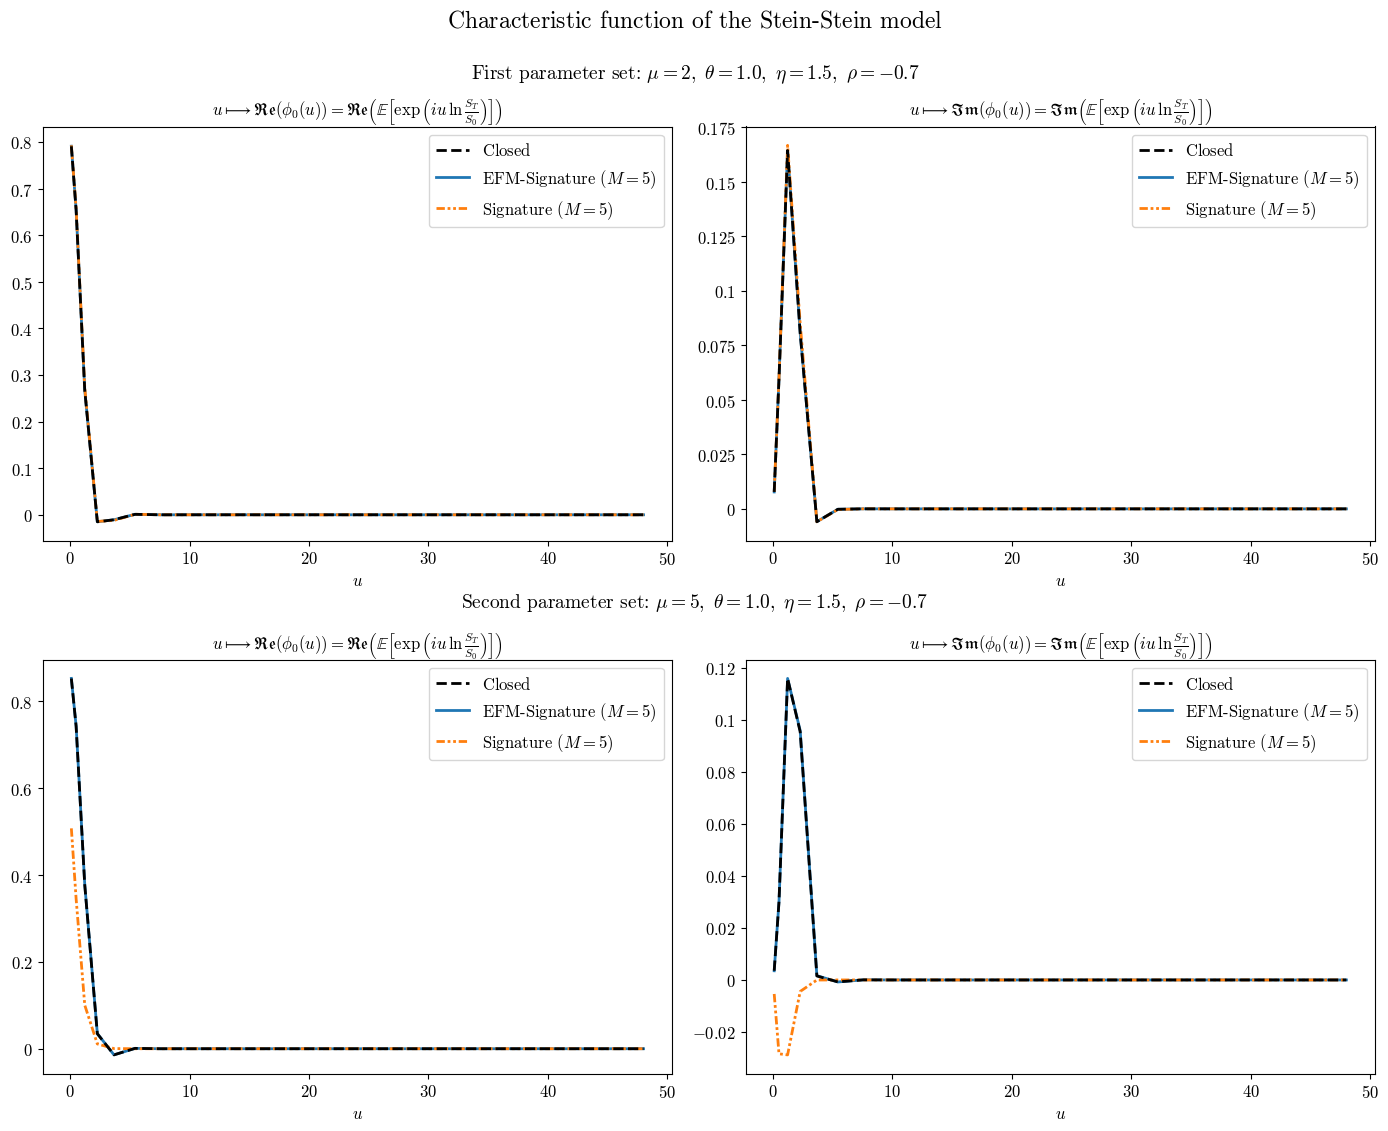

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11.5))
ax = ax.flatten() 

ax[0].plot(u_1, phi_SS_1.real, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[0].plot(u_1, phi_EFM_1.real, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[0].plot(u_1, phi_sig_1.real, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].set_title(r"$u\longmapsto\mathfrak{Re}(\phi_0(u))= \mathfrak{Re}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[1].plot(u_1, phi_SS_1.imag, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[1].plot(u_1, phi_EFM_1.imag, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[1].plot(u_1, phi_sig_1.imag, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[1].set_title(r"$u\longmapsto\mathfrak{Im}(\phi_0(u)) = \mathfrak{Im}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[2].plot(u_2, phi_SS_2.real, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[2].plot(u_2, phi_EFM_2.real, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[2].plot(u_2, phi_sig_2.real, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].set_title(r"$u\longmapsto\mathfrak{Re}(\phi_0(u))= \mathfrak{Re}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[3].plot(u_2, phi_SS_2.imag, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[3].plot(u_2, phi_EFM_2.imag, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[3].plot(u_2, phi_sig_2.imag, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[3].set_title(r"$u\longmapsto\mathfrak{Im}(\phi_0(u)) = \mathfrak{Im}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)


for i in range(4) :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$u$", fontsize=12)
    ax[i].legend(fontsize=12)


fig.suptitle(r"$\text{Characteristic function of the Stein-Stein model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \mu={mu_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \mu={mu_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

### I.2. Absolute error on European call prices and implied volatilities

In [10]:
K_values = np.linspace(0.3 * S0, 1.7 * S0, 500)

N_mc, n_mc = 100000, 252 
Z = simulate_antithetic(N_mc, n_mc, d=2) 
S_1, _ = simulate_SteinStein(N_mc, n_mc, T, S0, x_1, mu_1, theta_1, eta_1, rho_1, Z)
S_2, _ = simulate_SteinStein(N_mc, n_mc, T, S0, x_2, mu_2, theta_2, eta_2, rho_2, Z)

In [11]:
L = 35
u_grid, _ = laggauss(L)
u_grid_shifted = u_grid * 1j + 0.5
v_grid = jnp.array([0.0 +0.0j])

psi_EFM_1 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_1, lambd_1, rho_1, shuffle_table, t_grid=t_main, M=M, d=d)
W0_1 = EFM_sig_1[:, 0, 0].astype(jnp.complex128)
psi_EFM_2 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_2, lambd_2, rho_2, shuffle_table, t_grid=t_main, M=M, d=d)
W0_2 = EFM_sig_2[:, 0, 0].astype(jnp.complex128)

phi_SS_1 = compute_SteinStein_char_func(T, u_grid, x_1, mu_1, theta_1, eta_1, rho_1)
phi_SS_2 = compute_SteinStein_char_func(T, u_grid, x_2, mu_2, theta_2, eta_2, rho_2)

n = 252  

u_1, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array[1:]), x_1, M, L, n)
psi_sig_1 = compute_psi_char_func(T, rho_1, u_1, sigma_1, sigma_2_1, projectors_1, tuples_1)
phi_sig_1 = np.exp(psi_sig_1[:, 0, 0])

u_2, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array[1:]), x_2, M, L, n)
psi_sig_2 = compute_psi_char_func(T, rho_2, u_2, sigma_2, sigma_2_2, projectors_2, tuples_2)
phi_sig_2 = np.exp(psi_sig_2[:, 0, 0])

In [12]:
prices_closed_1, prices_EFM_1, prices_sig_1, prices_MC_1, prices_MC_lower_1, prices_MC_upper_1 = [], [], [], [], [], []
prices_closed_2, prices_EFM_2, prices_sig_2, prices_MC_2, prices_MC_lower_2, prices_MC_upper_2 = [], [], [], [], [], []

for K in tqdm(K_values) : 
    prices_closed_1.append(compute_europ_Fourier(phi_SS_1, S0, K))
    prices_EFM_1.append(compute_europ_Fourier_EFM_sig(psi_EFM_1, W0_1, S0, K))
    prices_sig_1.append(compute_europ_Fourier_sig(psi_sig_1, S0, K))
    mean, _, lower, upper = monte_carlo(np.maximum(S_1[:, -1] - K, 0.0))
    prices_MC_1.append(mean)
    prices_MC_lower_1.append(lower)
    prices_MC_upper_1.append(upper)

    prices_closed_2.append(compute_europ_Fourier(phi_SS_2, S0, K))
    prices_EFM_2.append(compute_europ_Fourier_EFM_sig(psi_EFM_2, W0_2, S0, K))
    prices_sig_2.append(compute_europ_Fourier_sig(psi_sig_2, S0, K))
    mean, _, lower, upper = monte_carlo(np.maximum(S_2[:, -1] - K, 0.0))
    prices_MC_2.append(mean)
    prices_MC_lower_2.append(lower)
    prices_MC_upper_2.append(upper)

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 224.59it/s]


In [13]:
logmoneyness = np.log(K_values/S0) 

iv_closed_1 = compute_IV(logmoneyness, T, S0, phi_SS_1)
iv_MC_1, iv_MC_lower_1, iv_MC_upper_1 = compute_IV_MC(logmoneyness, T, S0, S_1[:, -1])
iv_sig_1, _ = compute_IV_sig_and_penalty(logmoneyness, T, S0, psi_sig_1)
iv_EFM_1 = compute_IV_EFM_sig(logmoneyness, T, S0, psi_EFM_1, W0_1)
iv_closed_2 = compute_IV(logmoneyness, T, S0, phi_SS_2)
iv_MC_2, iv_MC_lower_2, iv_MC_upper_2 = compute_IV_MC(logmoneyness, T, S0, S_2[:, -1])
iv_sig_2, _ = compute_IV_sig_and_penalty(logmoneyness, T, S0, psi_sig_2)
iv_EFM_2 = compute_IV_EFM_sig(logmoneyness, T, S0, psi_EFM_2, W0_2)

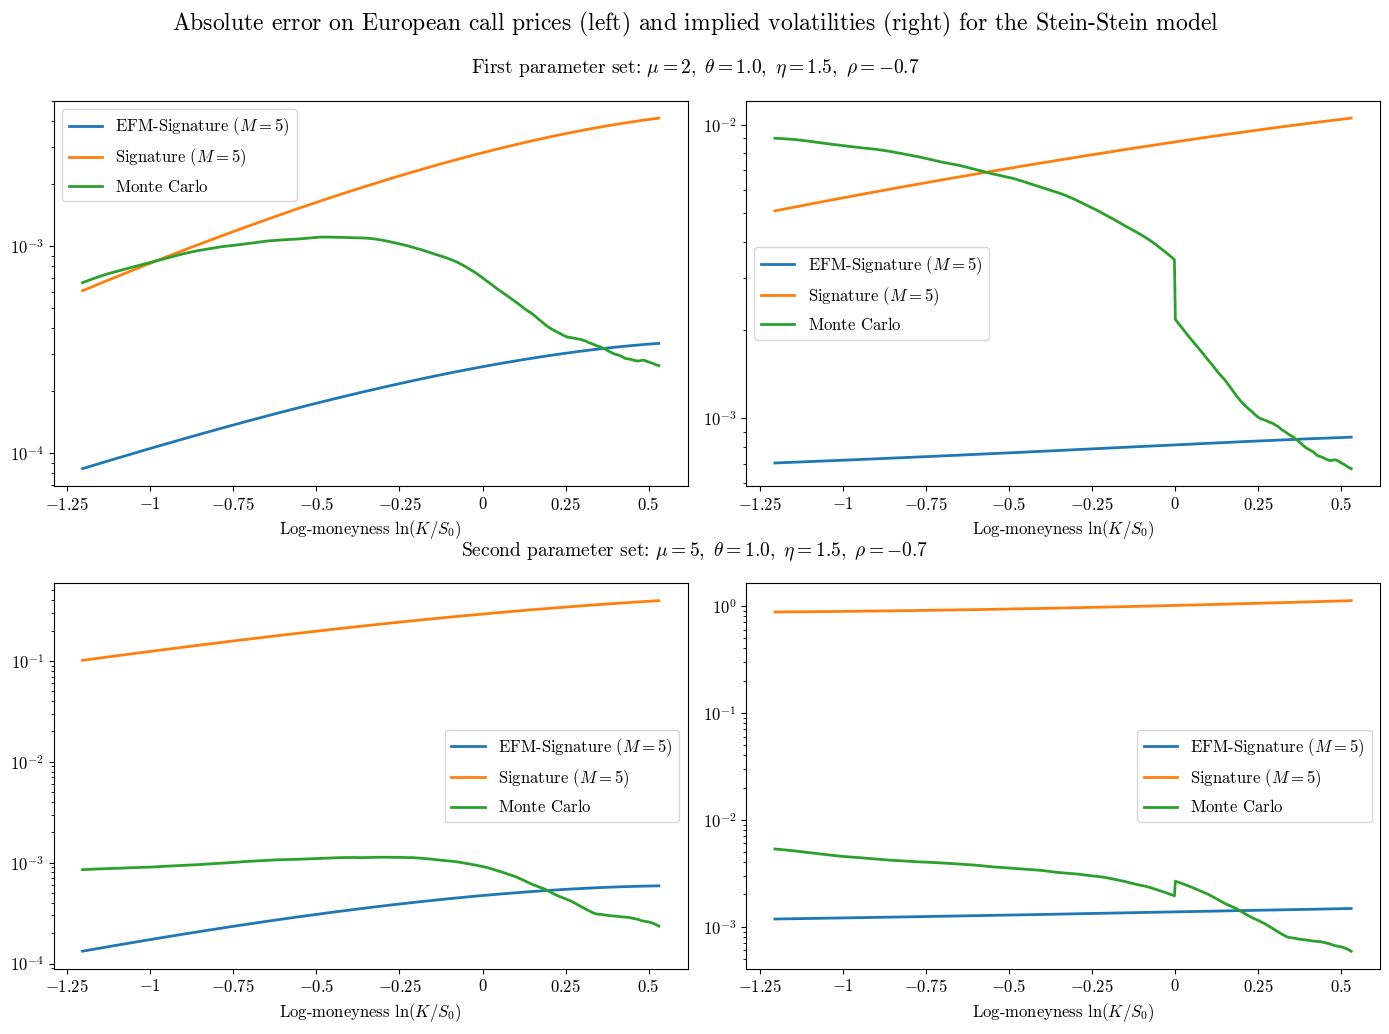

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))
ax = ax.flatten() 

ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_EFM_1)), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_sig_1)), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_MC_1)), lw=2, label=r"$\text{Monte Carlo}$")

ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_EFM_1), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_sig_1), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_MC_1), lw=2, label=r"$\text{Monte Carlo}$")

ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_EFM_2)), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_sig_2)), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_MC_2)), lw=2, label=r"$\text{Monte Carlo}$")

ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_EFM_2), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_sig_2), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_MC_2), lw=2, label=r"$\text{Monte Carlo}$")

for i in range(4) : 
    ax[i].legend(loc="best", fontsize=12)
    ax[i].set_xlabel(r"$\text{Log-moneyness }\ln(K/S_0)$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$"))
    ax[i].tick_params(axis='both', labelsize=12) 

fig.suptitle(r"$\text{Absolute error on European call prices (left) and implied volatilities (right) for the Stein-Stein model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \mu={mu_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \mu={mu_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

### I.3. $q$-Volatility swaps

In [17]:
T = 2
T0 = -50 
n1 = 3000  
n2 = T * 365 * 5 + 1
N = 1
M, d = 4, 2 
shuffle_table = get_shuffle_table(M=M, d=d)
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=38)
S0 = 1 

lambd_1 = jnp.array([2.0, 2.0])
mu_1, theta_1, eta_1, rho_1 = 2, 1.0, 1.5, -0.7
lambd_2 = jnp.array([5.0, 5.0])
mu_2, theta_2, eta_2, rho_2 = 5, 1.0, 1.5, -0.7

l_EFM_1 = compute_l_EFM_OU(lambd_1, mu_1, theta_1, eta_1, M, x=theta_1)
EFM_sig_1 = compute_EFM_signature(paths, t_grid, lambd_1, M)
l_EFM_2 = compute_l_EFM_OU(lambd_2, mu_2, theta_2, eta_2, M, x=theta_2)
EFM_sig_2 = compute_EFM_signature(paths, t_grid, lambd_2, M)

X_true_1 = simulate_Langevin_Euler(theta_1, mu_1, theta_1, eta_1, paths)
x_1 = X_true_1[0, len(t_burn)]
X_true_2 = simulate_Langevin_Euler(theta_2, mu_2, theta_2, eta_2, paths)
x_2 = X_true_2[0, len(t_burn)]

l_1 = compute_l_OU(x_1, mu_1, theta_1, eta_1, M, d, shuffle_table)
sig_1 = compute_signature(paths[:, len(t_burn):, :], M)
l_2 = compute_l_OU(x_2, mu_2, theta_2, eta_2, M, d, shuffle_table)
sig_2 = compute_signature(paths[:, len(t_burn):, :], M)

Z = np.diff(paths[:, len(t_burn):, 1]) / np.sqrt(t_main[-1] - t_main[-2])
Z2 = np.zeros((1, len(t_main), 2))
Z2[:, 1:, 0] = Z

_, X_exact_1 = simulate_SteinStein(1, len(t_main)-1, T, S0, x_1, mu_1, theta_1, eta_1, rho_1, Z2)
_, X_exact_2 = simulate_SteinStein(1, len(t_main)-1, T, S0, x_2, mu_2, theta_2, eta_2, rho_2, Z2)

In [18]:
U_max = 100
q = 0.5
L = 100
u, w =  gauss_legendre_interval(L, np.sqrt(U_max))
u_grid = jnp.array([0.0])

_, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array)[1:], x_1, M, L, n=252)
_, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array)[1:], x_2, M, L, n=252)

In [29]:
T_values = np.linspace(1/52, T, 50)

W0_1 = EFM_sig_1[:, 0, 0]
W0_2 = EFM_sig_2[:, 0, 0]

In [30]:
values_EFM_vol_1, values_EFM_var_1 = [], []
values_sig_vol_1, values_sig_var_1 = [], []

values_EFM_vol_2, values_EFM_var_2 = [], []
values_sig_vol_2, values_sig_var_2 = [], []

E_lambd_1 = expected_bm_EFM_signature(M, lambd_1) 
E_lambd_2 = expected_bm_EFM_signature(M, lambd_2) 

l_EFM_sq_1 = shuffle_pow(l_EFM_1, p=2, shuffle_table=shuffle_table)
l_EFM_sq_2 = shuffle_pow(l_EFM_2, p=2, shuffle_table=shuffle_table)

l_sq_1 = shuffle_pow(l_1, p=2, shuffle_table=shuffle_table)
l_sq_1_1 = tensor_prod_word(l_sq_1, word=1)

l_sq_2 = shuffle_pow(l_2, p=2, shuffle_table=shuffle_table)
l_sq_1_2 = tensor_prod_word(l_sq_2, word=1)

for T in tqdm(T_values) : 
    v_grid = jnp.array(-u**2/T)
    t_main_T = jnp.linspace(0.0, T, max(int(T * 365 * 5), 500) + 1)
    psi_EFM_1 = solve_Riccati_EFM_vol(u_grid, v_grid, l_EFM_1, lambd_1, rho_1, shuffle_table, t_main_T, M, d).real
    psi_EFM_2 = solve_Riccati_EFM_vol(u_grid, v_grid, l_EFM_2, lambd_2, rho_2, shuffle_table, t_main_T, M, d).real
    
    values_EFM_vol_1.append(float(compute_vol_swap_EFM_sig(u, w, psi_EFM_1, W0_1, U_max, q=0.5)))
    values_EFM_vol_2.append(float(compute_vol_swap_EFM_sig(u, w, psi_EFM_2, W0_2, U_max, q=0.5)))
    
    values_EFM_var_1.append(compute_variance_swap_EFM_sig(EFM_sig_1, t_main_T, lambd_1, M, l_EFM_sq_1)) 
    values_EFM_var_2.append(compute_variance_swap_EFM_sig(EFM_sig_2, t_main_T, lambd_2, M, l_EFM_sq_2)) 
    
    psi_1 = compute_psi_vol_swap(T, rho_1, u**2, sigma_1, sigma_2_1, projectors_1, tuples_1)
    psi_2 = compute_psi_vol_swap(T, rho_2, u**2, sigma_2, sigma_2_2, projectors_2, tuples_2)

    values_sig_vol_1.append(compute_vol_swap(u, w, psi_1, U_max))
    values_sig_vol_2.append(compute_vol_swap(u, w, psi_2, U_max))
    
    E = Tensor(array=expected_bm_signature(t=T, M=M)[:, 0], M=M, d=d)
    bracket_1 = float(l_sq_1_1 @ E)
    bracket_2 = float(l_sq_1_2 @ E)
    values_sig_var_1.append(1/T * bracket_1)
    values_sig_var_2.append(1/T * bracket_2)

100%|███████████████████████████████████████████| 50/50 [02:57<00:00,  3.56s/it]


In [31]:
N_mc, n_mc = 200000, 252

values_mc_vol_1, values_mc_lower_vol_1, values_mc_upper_vol_1 = [], [], []
values_mc_var_1, values_mc_lower_var_1, values_mc_upper_var_1 = [], [], []

values_mc_vol_2, values_mc_lower_vol_2, values_mc_upper_vol_2 = [], [], []
values_mc_var_2, values_mc_lower_var_2, values_mc_upper_var_2 = [], [], []

for i, T in enumerate(tqdm(T_values)) : 
    W = generate_brownian_paths(N_mc, n_mc, T, antithetic=True)
    X_1 = simulate_OU_euler(x_1, T, mu_1, theta_1, eta_1, W)
    X_2 = simulate_OU_euler(x_2, T, mu_2, theta_2, eta_2, W)
    V_T_1 = compute_integrated_variance(X_1, T)
    V_T_2 = compute_integrated_variance(X_2, T)
    
    sample_1 = np.sqrt(V_T_1 / T)
    mid, _, lower, upper = monte_carlo(sample_1) 
    values_mc_vol_1.append(mid); values_mc_lower_vol_1.append(lower); values_mc_upper_vol_1.append(upper)
    sample_2 = np.sqrt(V_T_2 / T)
    mid, _, lower, upper = monte_carlo(sample_2) 
    values_mc_vol_2.append(mid); values_mc_lower_vol_2.append(lower); values_mc_upper_vol_2.append(upper)

    sample_1 = V_T_1 / T
    mid, _, lower, upper = monte_carlo(sample_1) 
    values_mc_var_1.append(mid); values_mc_lower_var_1.append(lower); values_mc_upper_var_1.append(upper)
    sample_2 = V_T_2 / T
    mid, _, lower, upper = monte_carlo(sample_2) 
    values_mc_var_2.append(mid); values_mc_lower_var_2.append(lower); values_mc_upper_var_2.append(upper)

100%|███████████████████████████████████████████| 50/50 [01:56<00:00,  2.32s/it]


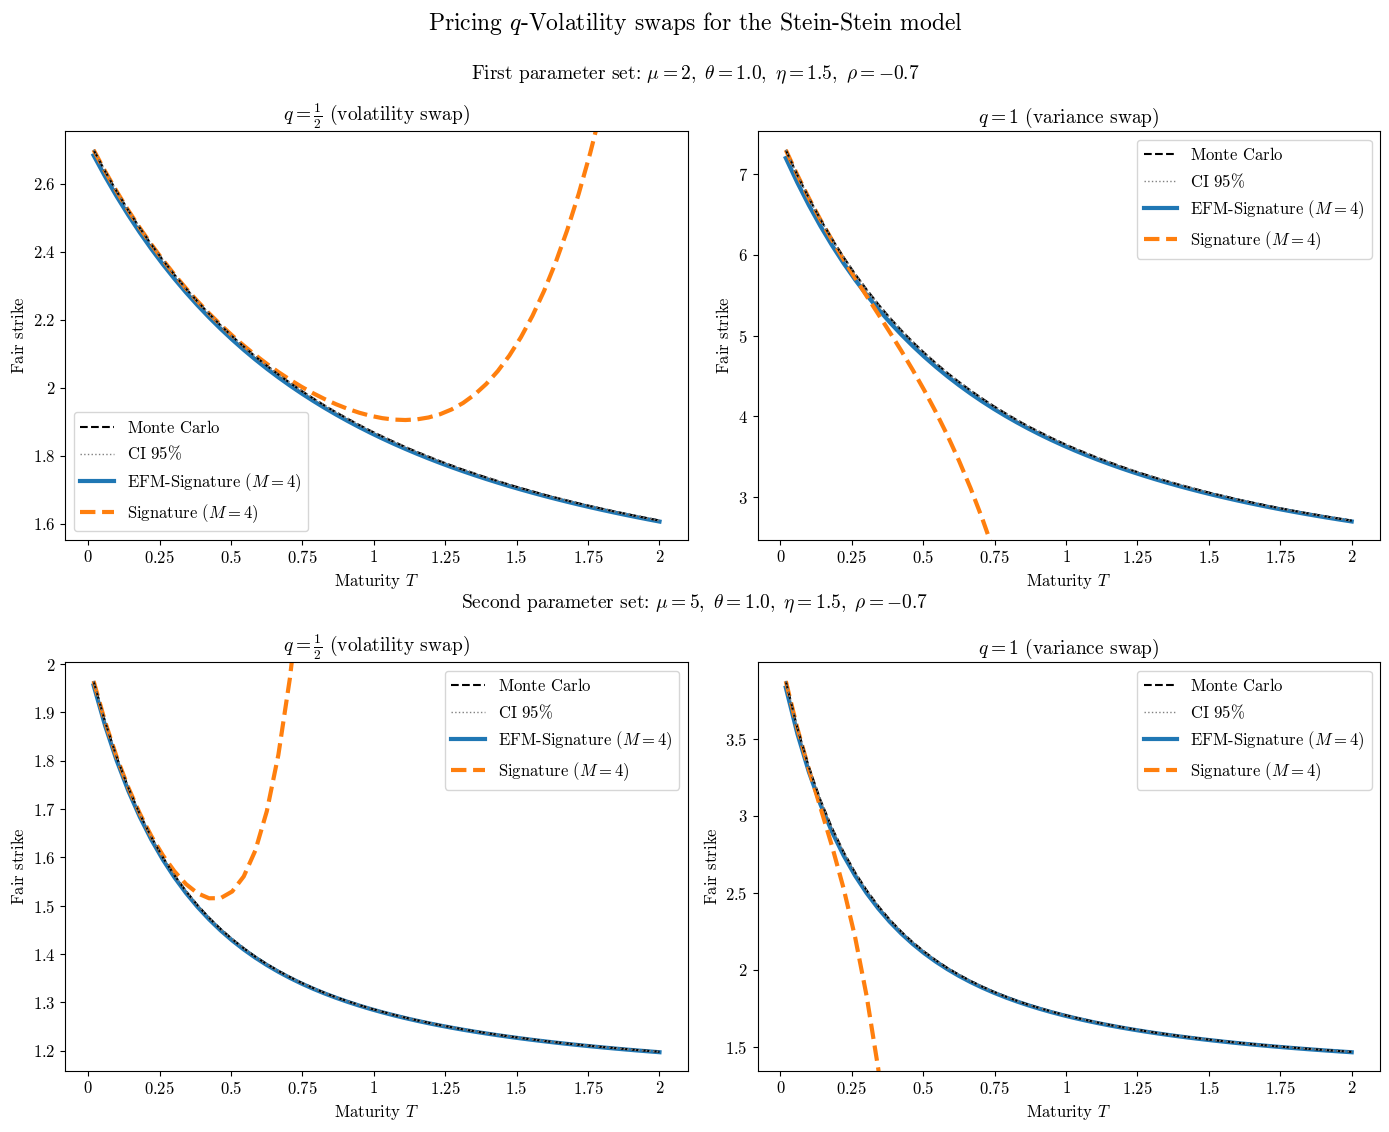

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11.5))
ax = ax.flatten() 

ax[0].plot(T_values, values_mc_vol_1, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[0].plot(T_values, values_mc_lower_vol_1, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[0].plot(T_values, values_mc_upper_vol_1, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[0].get_ylim() 
ax[0].plot(T_values, values_EFM_vol_1, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[0].plot(T_values, values_sig_vol_1, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[0].set_ylim(lims)

ax[1].plot(T_values, values_mc_var_1, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[1].plot(T_values, values_mc_lower_var_1, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[1].plot(T_values, values_mc_upper_var_1, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[1].get_ylim() 
ax[1].plot(T_values, values_EFM_var_1, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[1].plot(T_values, values_sig_var_1, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[1].set_ylim(lims)

ax[2].plot(T_values, values_mc_vol_2, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[2].plot(T_values, values_mc_lower_vol_2, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[2].plot(T_values, values_mc_upper_vol_2, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[2].get_ylim() 
ax[2].plot(T_values, values_EFM_vol_2, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[2].plot(T_values, values_sig_vol_2, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[2].set_ylim(lims)

ax[3].plot(T_values, values_mc_var_2, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[3].plot(T_values, values_mc_lower_var_2, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[3].plot(T_values, values_mc_upper_var_2, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[3].get_ylim() 
ax[3].plot(T_values, values_EFM_var_2, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[3].plot(T_values, values_sig_var_2, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[3].set_ylim(lims)

ax[0].set_title(r"$q =\frac{1}{2} \text{ (volatility swap)}$", fontsize=14)
ax[2].set_title(r"$q =\frac{1}{2} \text{ (volatility swap)}$", fontsize=14)
ax[1].set_title(r"$q =1 \text{ (variance swap)}$", fontsize=14)
ax[3].set_title(r"$q =1 \text{ (variance swap)}$", fontsize=14)

for i in range(4) :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$\text{Maturity } T$", fontsize=12)
    ax[i].set_ylabel(r"$\text{Fair strike}$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Pricing }q\text{-Volatility swaps for the Stein-Stein model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \mu={mu_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \mu={mu_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

## II. Heston model 

In [224]:
T = 4
T0_1, T0_2 = -4, -2
n1_1, n1_2 = 500, 1500
n2 = T * 365 * 5 + 1
N = 1
M, d = 5, 2 
shuffle_table = get_shuffle_table(M=M, d=d)
paths_1, t_burn_1, t_main_1, t_grid_1 = generate_two_sided_brownian_paths(N, n1_1, n2, T, T0_1)
paths_2, t_burn_2, t_main_2, t_grid_2 = generate_two_sided_brownian_paths(N, n1_2, n2, T, T0_2)
S0 = 1 

### II.1. Signature representation and characteristic function 

In [225]:
v_1, theta_1, kappa_1, eta_1, rho_1 = 0.0625, 0.0625, 1, 0.2, -0.7 
v_2, theta_2, kappa_2, eta_2, rho_2 = 0.0625, 0.0625, 4, 0.7, -0.7 

print("Feller condition (set 1):", 2*kappa_1*theta_1, "\geq?", eta_1**2)
print("Feller condition (set 2):", 2*kappa_2*theta_2, "\geq?", eta_2**2)


X_true_1 = simulate_CIR_QE_on_R(v_1, kappa_1, theta_1, eta_1, paths_1)
x_1 = X_true_1[0, len(t_burn_1)]
X_markov_1 = simulate_CIR_QE(x_1, t_main_1[-1], kappa_1, theta_1, eta_1, paths_1[:, len(t_burn_1):, 1])

X_true_2 = simulate_CIR_QE_on_R(v_2, kappa_2, theta_2, eta_2, paths_2)
x_2 = X_true_2[0, len(t_burn_2)]
X_markov_2 = simulate_CIR_QE(x_2, t_main_2[-1], kappa_2, theta_2, eta_2, paths_2[:, len(t_burn_2):, 1])

idx_train = int(0.75 * n2)
idx_val = int(n2) 

Y_1 = X_true_1[0, len(t_burn_1):]
Y_2 = X_true_2[0, len(t_burn_2):]

l_1_ = compute_l_CIR(np.sqrt(x_1), kappa_1, theta_1, eta_1, M)
l_1 = Tensor(array=jnp.concat([jnp.asarray([x_1]), jnp.asarray(l_1_)]), M=M, d=d)
sig_1 = compute_signature(paths_1[:, len(t_burn_1):, :], M)

l_2_ = compute_l_CIR(np.sqrt(x_2), kappa_2, theta_2, eta_2, M)
l_2 = Tensor(array=jnp.concat([jnp.asarray([x_2]), jnp.asarray(l_2_)]), M=M, d=d)
sig_2 = compute_signature(paths_2[:, len(t_burn_2):, :], M)

Feller condition (set 1): 0.125 \geq? 0.04000000000000001
Feller condition (set 2): 0.5 \geq? 0.48999999999999994


In [226]:
x_1, x_2

(np.float64(0.037128831052186485), np.float64(0.1163164485994303))

In [7]:
bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 
lambda_opt_1 = minimize_lambda(paths_1[0], Y_1, M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)

lambda=[5. 5.] | RMSE=0.02384628
lambda=[7.70112362 5.        ] | RMSE=0.02448511
lambda=[12.39887638  5.        ] | RMSE=0.02540036
lambda=[4.79775275 5.        ] | RMSE=0.02358428
lambda=[3.00337087 5.        ] | RMSE=0.01989529
lambda=[1.89438188 5.        ] | RMSE=0.01680168
lambda=[1.20898899 5.        ] | RMSE=0.01320004
lambda=[0.78539289 5.        ] | RMSE=0.01248795
lambda=[0.73636617 5.        ] | RMSE=0.01298551
lambda=[0.96361037 5.        ] | RMSE=0.01258107
lambda=[0.85346591 5.        ] | RMSE=0.01241016
lambda=[0.85722338 5.        ] | RMSE=0.01241206
lambda=[0.84432311 5.        ] | RMSE=0.01240770
lambda=[0.82181377 5.        ] | RMSE=0.01241702
lambda=[0.84163054 5.        ] | RMSE=0.01240762
lambda=[0.84214031 5.        ] | RMSE=0.01240761
lambda=[0.8424737 5.       ] | RMSE=0.01240761
lambda=[0.84214031 7.70112362] | RMSE=0.02012163
lambda=[ 0.84214031 12.39887638] | RMSE=0.02573960
lambda=[0.84214031 4.79775275] | RMSE=0.01163385
lambda=[0.84214031 3.00337087] | R

In [227]:
lambd_1 = jnp.array([0.49059747, 0.89582289]) 
EFM_sig_1 = compute_EFM_signature(paths_1, t_grid_1, lambd_1, M) 
start = time.time() 
model_EFM_Ridge_1, Y_EFM_Ridge_1, rmse_EFM_Ridge_1 = regression_Ridge(Y_1, EFM_sig_1[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge_1) 

coef_EFM_1 = get_full_coef(model_EFM_Ridge_1)
l_EFM_1 = Tensor(array=jnp.asarray(coef_EFM_1), M=M, d=d)

Ridge:  0.5600168704986572  seconds, RMSE: 2.856126699302078e-05


In [228]:
bounds = [(0.1, 5), (0.1, 5)]
init_guess = [2] * d 
lambda_opt_2 = minimize_lambda(paths_2[0], Y_2, M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)

lambda=[2. 2.] | RMSE=0.00240020
lambda=[1.97163346 2.        ] | RMSE=0.00240410
lambda=[3.12836654 2.        ] | RMSE=0.00158196
lambda=[3.84326691 2.        ] | RMSE=0.00303734
lambda=[2.79217018 2.        ] | RMSE=0.00133801
lambda=[2.75301036 2.        ] | RMSE=0.00133732
lambda=[2.76792451 2.        ] | RMSE=0.00133690
lambda=[2.76759117 2.        ] | RMSE=0.00133690
lambda=[2.76825786 2.        ] | RMSE=0.00133690
lambda=[2.76792451 1.97163346] | RMSE=0.00137857
lambda=[2.76792451 3.12836654] | RMSE=0.00258793
lambda=[2.76792451 1.25673309] | RMSE=0.00390997
lambda=[2.76792451 2.33667517] | RMSE=0.00163698
lambda=[2.76792451 1.69856581] | RMSE=0.00222870
lambda=[2.76792451 2.09504678] | RMSE=0.00122331
lambda=[2.76792451 2.11065001] | RMSE=0.00120888
lambda=[2.76792451 2.19698394] | RMSE=0.00115252
lambda=[2.76792451 2.27609993] | RMSE=0.00113636
lambda=[2.76792451 2.27418843] | RMSE=0.00113636
lambda=[2.76792451 2.27517723] | RMSE=0.00113636
lambda=[2.76792451 2.29923761] | RMS

In [230]:
#lambd_2 = jnp.array([0.52850022, 1.04122616]) #0.00041922554788467015
#lambd_2 = jnp.array([0.34878959, 2.13430592])
lambd_2 = jnp.array([6.669e-01,  2.797e+00])
lambd_2 = jnp.array([ 2.667e+00,  2.276e+00])
EFM_sig_2 = compute_EFM_signature(paths_2, t_grid_2, lambd_2, M) 
start = time.time() 
model_EFM_Ridge_2, Y_EFM_Ridge_2, rmse_EFM_Ridge_2 = regression_Ridge(Y_2, EFM_sig_2[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge_2) 

coef_EFM_2 = get_full_coef(model_EFM_Ridge_2)
l_EFM_2 = Tensor(array=jnp.asarray(coef_EFM_2), M=M, d=d)

Ridge:  0.5493190288543701  seconds, RMSE: 0.0014790089157925657


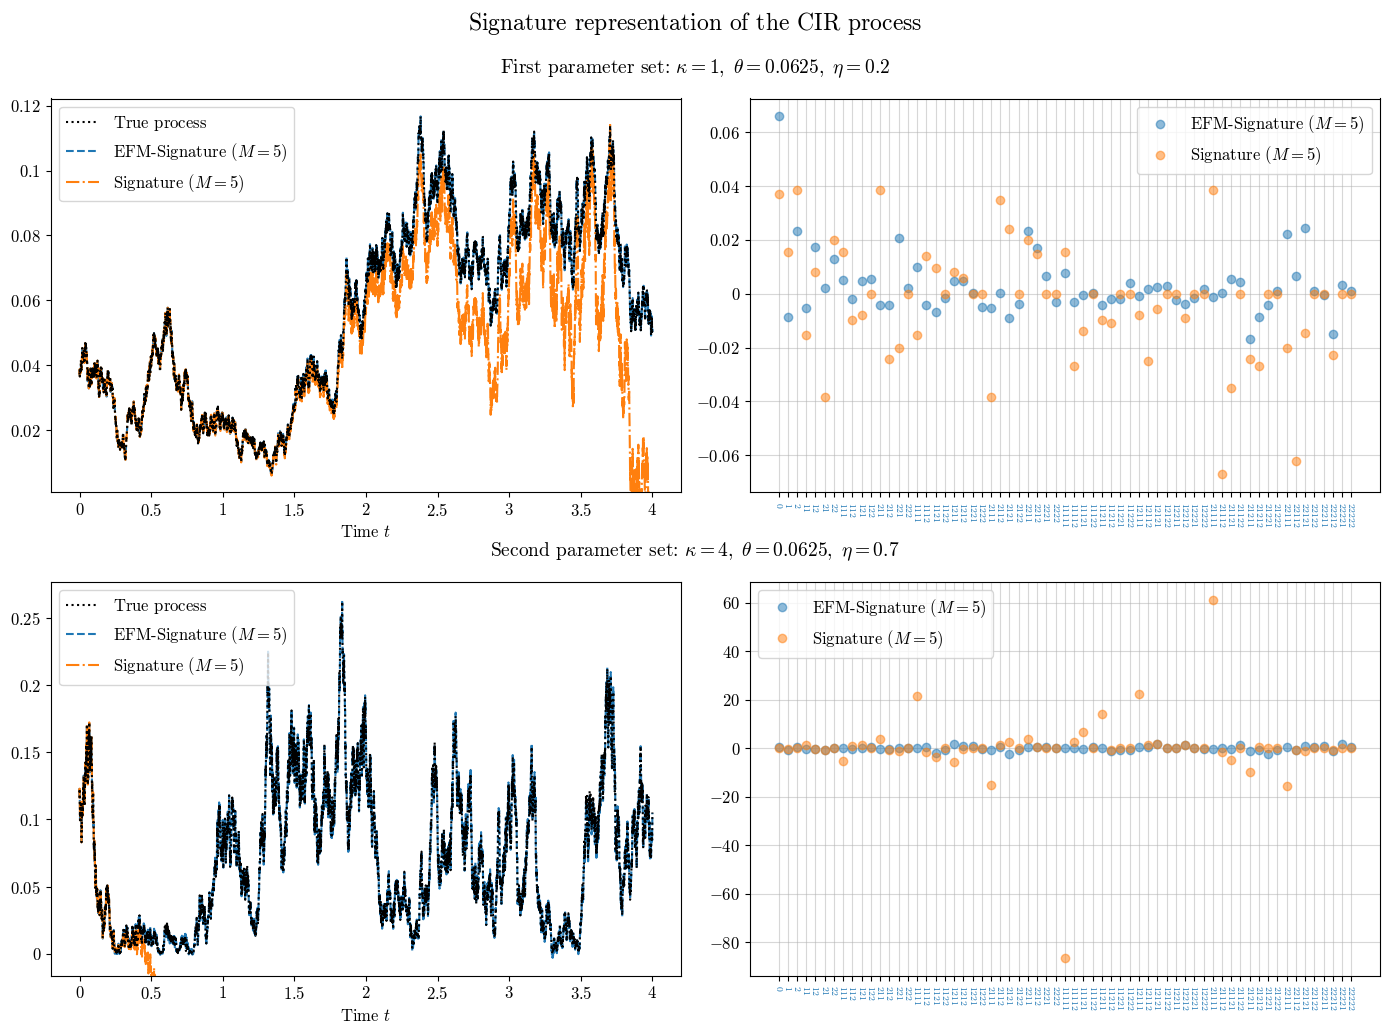

In [231]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))
ax = ax.flatten() 

ax[0].plot(t_main_1, X_true_1[0, len(t_burn_1):], color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[0].plot(t_main_1, (EFM_sig_1 @ l_EFM_1).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[0].get_ylim()
ax[0].plot(t_main_1, (sig_1 @ l_1).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].set_ylim(lims)

l_EFM_1.plot(ax=ax[1], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_1.plot(ax=ax[1], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

ax[2].plot(t_main_2, X_true_2[0, len(t_burn_2):], color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[2].plot(t_main_2, (EFM_sig_2 @ l_EFM_2).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[2].get_ylim()
ax[2].plot(t_main_2, (sig_2 @ l_2).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].set_ylim(lims)

l_EFM_2.plot(ax=ax[3], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_2.plot(ax=ax[3], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

for i in [0, 2] :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Signature representation of the CIR process}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \kappa={kappa_1},\ \theta={theta_1},\ \eta={eta_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \kappa={kappa_2},\ \theta={theta_2},\ \eta={eta_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

In [232]:
l_1_ = dict_to_vector(compute_sigma_CIR(np.sqrt(x_1), kappa_1, theta_1, eta_1, M), d, M)
l_1 = Tensor(array=jnp.concat([jnp.asarray([np.sqrt(x_1)]), jnp.asarray(l_1_)]), M=M, d=d)

l_2_ = dict_to_vector(compute_sigma_CIR(np.sqrt(x_2), kappa_2, theta_2, eta_2, M), d, M)
l_2 = Tensor(array=jnp.concat([jnp.asarray([np.sqrt(x_2)]), jnp.asarray(l_2_)]), M=M, d=d)

In [18]:
bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 
lambda_opt_1 = minimize_lambda(paths_1[0], np.sqrt(Y_1), M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)

lambda=[5. 5.] | RMSE=0.04636588
lambda=[7.70112362 5.        ] | RMSE=0.04838744
lambda=[12.39887638  5.        ] | RMSE=0.05225983
lambda=[4.79775275 5.        ] | RMSE=0.04575978
lambda=[3.00337087 5.        ] | RMSE=0.03758807
lambda=[1.89438188 5.        ] | RMSE=0.03110518
lambda=[1.20898899 5.        ] | RMSE=0.02509726
lambda=[0.78539289 5.        ] | RMSE=0.02415136
lambda=[0.80764971 5.        ] | RMSE=0.02385069
lambda=[0.968726 5.      ] | RMSE=0.02404745
lambda=[0.86917538 5.        ] | RMSE=0.02374964
lambda=[0.86695747 5.        ] | RMSE=0.02374739
lambda=[0.85673847 5.        ] | RMSE=0.02374161
lambda=[0.83798824 5.        ] | RMSE=0.02375380
lambda=[0.85402488 5.        ] | RMSE=0.02374144
lambda=[0.8545939 5.       ] | RMSE=0.02374143
lambda=[0.85492729 5.        ] | RMSE=0.02374143
lambda=[0.8545939  7.70112362] | RMSE=0.03941138
lambda=[ 0.8545939  12.39887638] | RMSE=0.05471000
lambda=[0.8545939  4.79775275] | RMSE=0.02237967
lambda=[0.8545939  3.00337087] | RMSE=

In [233]:
lambd_1 = jnp.array([0.73447821, 0.94787927]) #T0=-4, RMSE: 0.00020069845873457452 
EFM_sig_1 = compute_EFM_signature(paths_1, t_grid_1, lambd_1, M) 
start = time.time() 
model_EFM_Ridge_1, Y_EFM_Ridge_1, rmse_EFM_Ridge_1 = regression_Ridge(np.sqrt(Y_1), EFM_sig_1[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge_1) 

coef_EFM_1 = get_full_coef(model_EFM_Ridge_1)
l_EFM_1 = Tensor(array=jnp.asarray(coef_EFM_1), M=M, d=d)

Ridge:  0.5404188632965088  seconds, RMSE: 0.00020069845873457452


In [234]:
bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 

bounds = [(0.1, 5), (0.1, 5)]
init_guess = [2] * d 

lambda_opt_2 = minimize_lambda(paths_2[0], np.sqrt(Y_2), M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)

lambda=[2. 2.] | RMSE=0.00486464
lambda=[1.97163346 2.        ] | RMSE=0.00488532
lambda=[3.12836654 2.        ] | RMSE=0.00762184
lambda=[1.25673309 2.        ] | RMSE=0.00741550
lambda=[2.17507811 2.        ] | RMSE=0.00480338
lambda=[2.13231784 2.        ] | RMSE=0.00480462
lambda=[2.15991346 2.        ] | RMSE=0.00480258
lambda=[2.15856732 2.        ] | RMSE=0.00480257
lambda=[2.15890065 2.        ] | RMSE=0.00480257
lambda=[2.15923399 2.        ] | RMSE=0.00480257
lambda=[2.15890065 1.97163346] | RMSE=0.00488475
lambda=[2.15890065 3.12836654] | RMSE=0.00516466
lambda=[2.15890065 1.25673309] | RMSE=0.00833378
lambda=[2.15890065 2.50530483] | RMSE=0.00405024
lambda=[2.15890065 2.50825262] | RMSE=0.00405318
lambda=[2.15890065 2.40213823] | RMSE=0.00398672
lambda=[2.15890065 2.23770004] | RMSE=0.00430700
lambda=[2.15890065 2.36865794] | RMSE=0.00398316
lambda=[2.15890065 2.37115088] | RMSE=0.00398313
lambda=[2.15890065 2.37148422] | RMSE=0.00398313
lambda=[2.15890065 2.37240509] | RMS

In [235]:
lambd_2 = jnp.array([0.62305829, 1.91507268]) #Ridge:  0.6398367881774902  seconds, RMSE: 0.0025587400017058155 
lambd_2 = jnp.array([1.38198063, 1.16123001])
lambd_2 = jnp.array( [1.176e+00,  2.761e+00])
EFM_sig_2 = compute_EFM_signature(paths_2, t_grid_2, lambd_2, M) 
start = time.time() 
model_EFM_Ridge_2, Y_EFM_Ridge_2, rmse_EFM_Ridge_2 = regression_Ridge(np.sqrt(Y_2), EFM_sig_2[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge_2) 

coef_EFM_2 = get_full_coef(model_EFM_Ridge_2)
l_EFM_2 = Tensor(array=jnp.asarray(coef_EFM_2), M=M, d=d)

Ridge:  0.5512979030609131  seconds, RMSE: 0.0033110438015822134


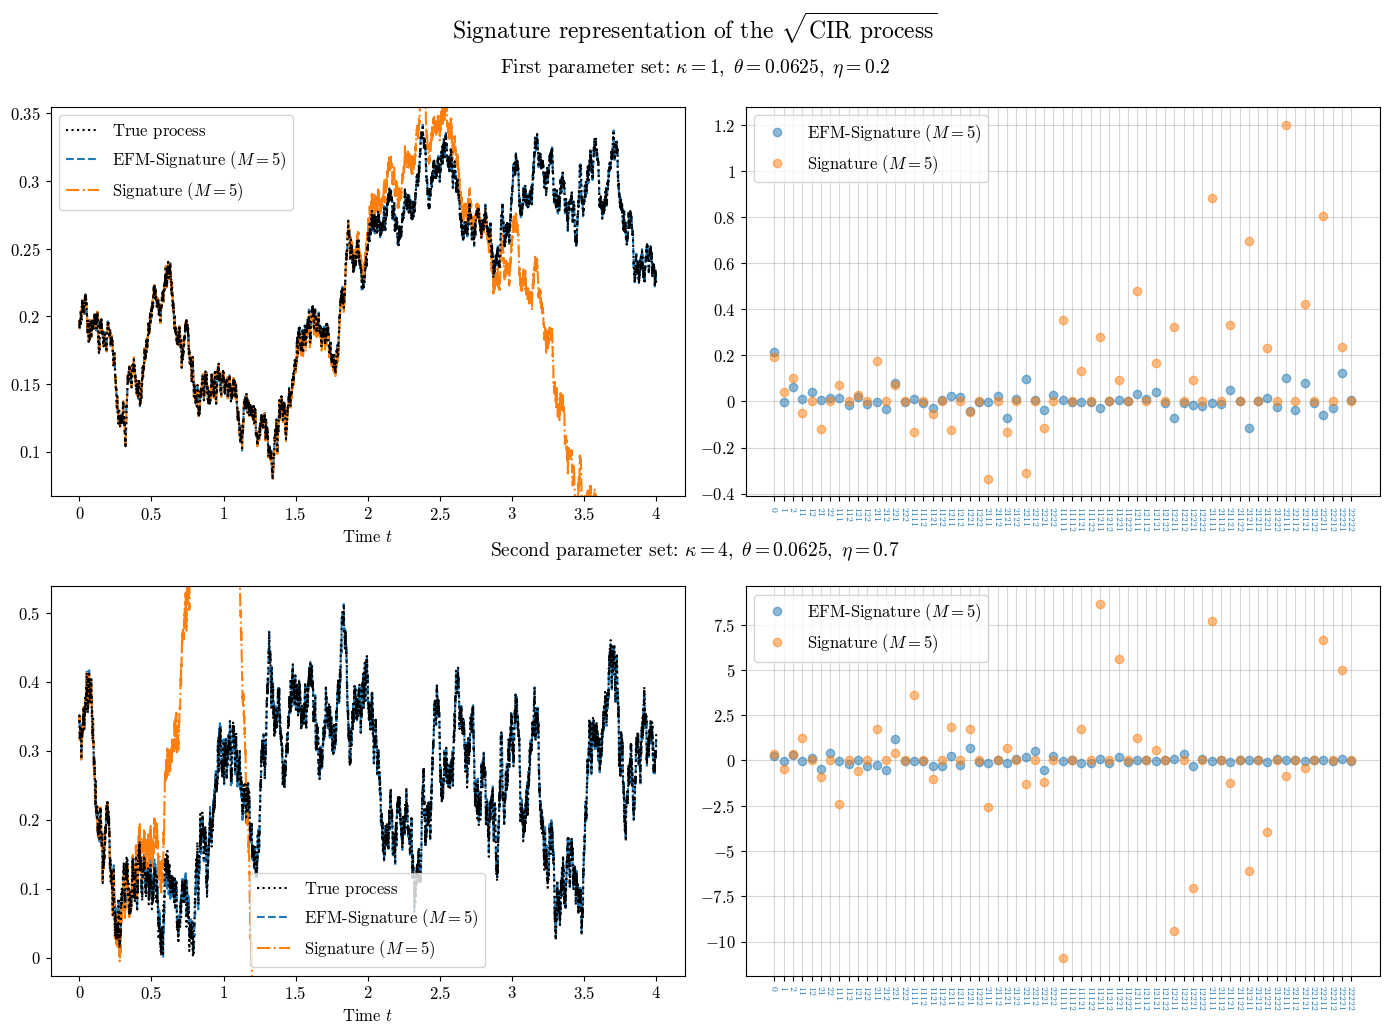

In [236]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))
ax = ax.flatten() 

ax[0].plot(t_main_1, np.sqrt(X_true_1[0, len(t_burn_1):]), color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[0].plot(t_main_1, (EFM_sig_1 @ l_EFM_1).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[0].get_ylim()
ax[0].plot(t_main_1, (sig_1 @ l_1).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].set_ylim(lims)

l_EFM_1.plot(ax=ax[1], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_1.plot(ax=ax[1], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

ax[2].plot(t_main_2, np.sqrt(X_true_2[0, len(t_burn_2):]), color="black", linestyle=":", label=r"$\text{True process}$", zorder=1)
ax[2].plot(t_main_2, (EFM_sig_2 @ l_EFM_2).T[0], linestyle="--", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
lims = ax[2].get_ylim()
ax[2].plot(t_main_2, (sig_2 @ l_2).T[0], linestyle="-.", zorder=0, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].set_ylim(lims)

l_EFM_2.plot(ax=ax[3], size_x=7, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$", alpha=0.5)
l_2.plot(ax=ax[3], size_x=7, label=r"$\text{Signature }$" + fr"$(M={M})$", alpha=0.5)

for i in [0, 2] :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Signature representation of the }\sqrt{\text{CIR process}}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \kappa={kappa_1},\ \theta={theta_1},\ \eta={eta_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \kappa={kappa_2},\ \theta={theta_2},\ \eta={eta_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

In [237]:
L = 10
u_grid, _ = laggauss(L)
u_grid_shifted = u_grid * 1j + 0.5
v_grid = jnp.array([0.0 +0.0j])

psi_EFM_1 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_1, lambd_1, rho_1, shuffle_table, t_grid=t_main_1, M=M, d=d)
W0_1 = EFM_sig_1[:, 0, 0].astype(jnp.complex128)
phi_EFM_1 = jnp.exp(psi_EFM_1[:, 0, :] @ W0_1)
psi_EFM_2 = solve_Riccati_EFM_vol(u_grid_shifted, v_grid, l_EFM_2, lambd_2, rho_2, shuffle_table, t_grid=t_main_2, M=M, d=d)
W0_2 = EFM_sig_2[:, 0, 0].astype(jnp.complex128)
phi_EFM_2 = jnp.exp(psi_EFM_2[:, 0, :] @ W0_2)

phi_Heston_1 = compute_Heston_char_func(T, u_grid, np.sqrt(x_1), kappa_1, theta_1, eta_1, rho_1)
phi_Heston_2 = compute_Heston_char_func(T, u_grid, np.sqrt(x_2), kappa_2, theta_2, eta_2, rho_2)

In [238]:
n = 252  

u_1, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array[1:]), np.sqrt(x_1), M, L, n)
psi_sig_1 = compute_psi_char_func(T, rho_1, u_1, sigma_1, sigma_2_1, projectors_1, tuples_1)
phi_sig_1 = np.exp(psi_sig_1[:, 0, 0])
u_2, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array[1:]), np.sqrt(x_2), M, L, n)
psi_sig_2 = compute_psi_char_func(T, rho_2, u_2, sigma_2, sigma_2_2, projectors_2, tuples_2)
phi_sig_2 = np.exp(psi_sig_2[:, 0, 0])

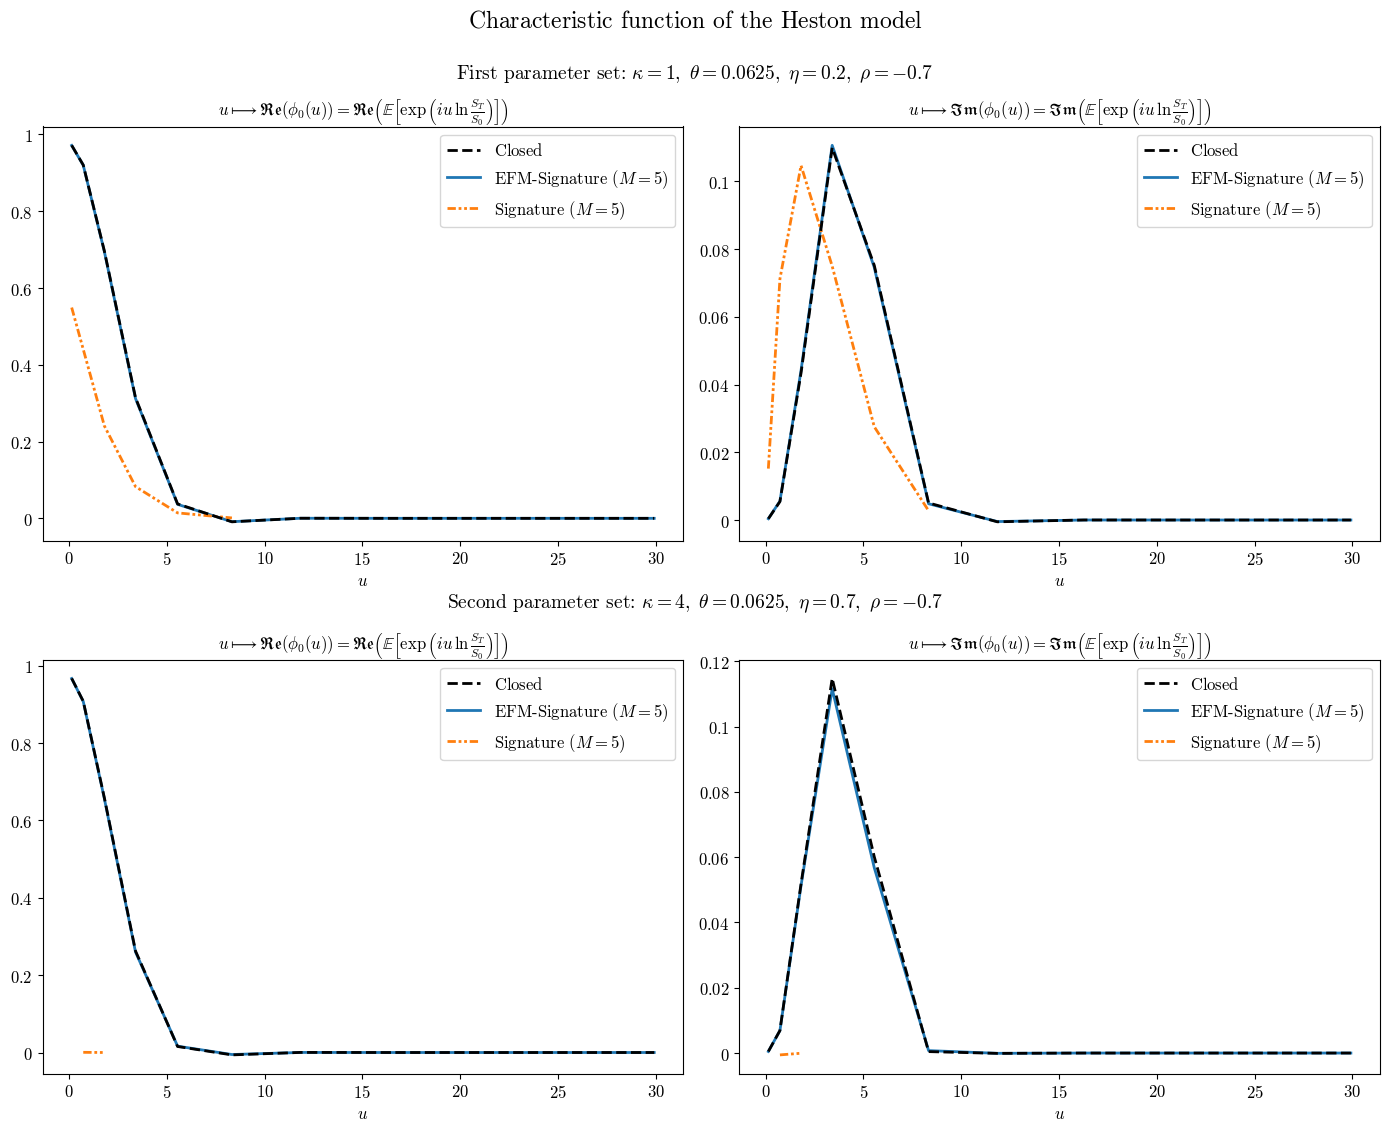

In [239]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11.5))
ax = ax.flatten() 

ax[0].plot(u_1, phi_Heston_1.real, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[0].plot(u_1, phi_EFM_1.real, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[0].plot(u_1, phi_sig_1.real, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].set_title(r"$u\longmapsto\mathfrak{Re}(\phi_0(u))= \mathfrak{Re}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[1].plot(u_1, phi_Heston_1.imag, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[1].plot(u_1, phi_EFM_1.imag, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[1].plot(u_1, phi_sig_1.imag, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[1].set_title(r"$u\longmapsto\mathfrak{Im}(\phi_0(u)) = \mathfrak{Im}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[2].plot(u_2, phi_Heston_2.real, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[2].plot(u_2, phi_EFM_2.real, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[2].plot(u_2, phi_sig_2.real, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].set_title(r"$u\longmapsto\mathfrak{Re}(\phi_0(u))= \mathfrak{Re}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

ax[3].plot(u_2, phi_Heston_2.imag, color="black", linestyle="--", zorder=1, lw=2, label=r"$\text{Closed}$")
ax[3].plot(u_2, phi_EFM_2.imag, zorder=0, lw=2, color="tab:blue", label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[3].plot(u_2, phi_sig_2.imag, zorder=0, lw=2, color="tab:orange", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[3].set_title(r"$u\longmapsto\mathfrak{Im}(\phi_0(u)) = \mathfrak{Im}\left(\mathbb{E}\left[\exp\left(iu\, \ln\frac{S_T}{S_0}\right)\right]\right)$", fontsize=12)

for i in range(4) :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$u$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Characteristic function of the Heston model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \kappa={kappa_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \kappa={kappa_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

### II.2. Absolute error on European call prices and implied volatilities

In [240]:
K_values = np.linspace(0.3 * S0, 1.7 * S0, 100)
logmoneyness = np.log(K_values/S0) 

N_mc, n_mc = 100000, 252 
Z = simulate_antithetic(N_mc, n_mc, d=2) 
eta_ = np.random.uniform(size=(N_mc, n_mc)) 

S_1, _ = simulate_Heston(S0, V0=x_1, T=T, a=kappa_1*theta_1, b=-kappa_1, c=eta_1, Z=Z, eta=eta_, rho=rho_1) #iVi scheme 
S_2, _ = simulate_Heston(S0, V0=x_2, T=T, a=kappa_2*theta_2, b=-kappa_2, c=eta_2, Z=Z, eta=eta_, rho=rho_2) #iVi scheme 

In [241]:
L_1 = 45
u_grid_1, _ = laggauss(L_1)
u_grid_shifted_1 = u_grid_1 * 1j + 0.5
v_grid_1 = jnp.array([0.0 +0.0j])

L_2 = 20
u_grid_2, _ = laggauss(L_2)
u_grid_shifted_2 = u_grid_2 * 1j + 0.5
v_grid_2 = jnp.array([0.0 +0.0j])

In [242]:
psi_EFM_1 = solve_Riccati_EFM_vol(u_grid_shifted_1, v_grid_1, l_EFM_1, lambd_1, rho_1, shuffle_table, t_grid=t_main_1, M=M, d=d)
W0_1 = EFM_sig_1[:, 0, 0].astype(jnp.complex128)
phi_EFM_1 = jnp.exp(psi_EFM_1[:, 0, :] @ W0_1)
psi_EFM_2 = solve_Riccati_EFM_vol(u_grid_shifted_2, v_grid_2, l_EFM_2, lambd_2, rho_2, shuffle_table, t_grid=t_main_2, M=M, d=d)
W0_2 = EFM_sig_2[:, 0, 0].astype(jnp.complex128)
phi_EFM_2 = jnp.exp(psi_EFM_2[:, 0, :] @ W0_2)

phi_Heston_1 = compute_Heston_char_func(T, u_grid_1, np.sqrt(x_1), kappa_1, theta_1, eta_1, rho_1)
phi_Heston_2 = compute_Heston_char_func(T, u_grid_2, np.sqrt(x_2), kappa_2, theta_2, eta_2, rho_2)

In [243]:
n = 252  

u_1, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array[1:]), np.sqrt(x_1), M, L_1, n)
psi_sig_1 = compute_psi_char_func(T, rho_1, u_1, sigma_1, sigma_2_1, projectors_1, tuples_1)
u_2, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array[1:]), np.sqrt(x_2), M, L_2, n)
psi_sig_2 = compute_psi_char_func(T, rho_2, u_2, sigma_2, sigma_2_2, projectors_2, tuples_2)

In [244]:
prices_closed_1, prices_EFM_1, prices_sig_1, prices_MC_1, prices_MC_lower_1, prices_MC_upper_1 = [], [], [], [], [], []
prices_closed_2, prices_EFM_2, prices_sig_2, prices_MC_2, prices_MC_lower_2, prices_MC_upper_2 = [], [], [], [], [], []

for K in K_values : 
    prices_closed_1.append(compute_europ_Fourier(phi_Heston_1, S0, K))
    prices_EFM_1.append(compute_europ_Fourier_EFM_sig(psi_EFM_1, W0_1, S0, K))
    prices_sig_1.append(compute_europ_Fourier_sig(psi_sig_1, S0, K))
    mean, _, lower, upper = monte_carlo(np.maximum(S_1[:, -1] - K, 0.0))
    prices_MC_1.append(mean)
    prices_MC_lower_1.append(lower)
    prices_MC_upper_1.append(upper)

    prices_closed_2.append(compute_europ_Fourier(phi_Heston_2, S0, K))
    prices_EFM_2.append(compute_europ_Fourier_EFM_sig(psi_EFM_2, W0_2, S0, K))
    prices_sig_2.append(compute_europ_Fourier_sig(psi_sig_2, S0, K))
    mean, _, lower, upper = monte_carlo(np.maximum(S_2[:, -1] - K, 0.0))
    prices_MC_2.append(mean)
    prices_MC_lower_2.append(lower)
    prices_MC_upper_2.append(upper)

In [245]:
iv_closed_1 = compute_IV(logmoneyness, T, S0, phi_Heston_1)
iv_MC_1, iv_MC_lower_1, iv_MC_upper_1 = compute_IV_MC(logmoneyness, T, S0, S_1[:, -1])
iv_sig_1, _ = compute_IV_sig_and_penalty(logmoneyness, T, S0, psi_sig_1)
iv_EFM_1 = compute_IV_EFM_sig(logmoneyness, T, S0, psi_EFM_1, W0_1)

iv_closed_2 = compute_IV(logmoneyness, T, S0, phi_Heston_2)
iv_MC_2, iv_MC_lower_2, iv_MC_upper_2 = compute_IV_MC(logmoneyness, T, S0, S_2[:, -1])
iv_sig_2, _ = compute_IV_sig_and_penalty(logmoneyness, T, S0, psi_sig_2)
iv_EFM_2 = compute_IV_EFM_sig(logmoneyness, T, S0, psi_EFM_2, W0_2)

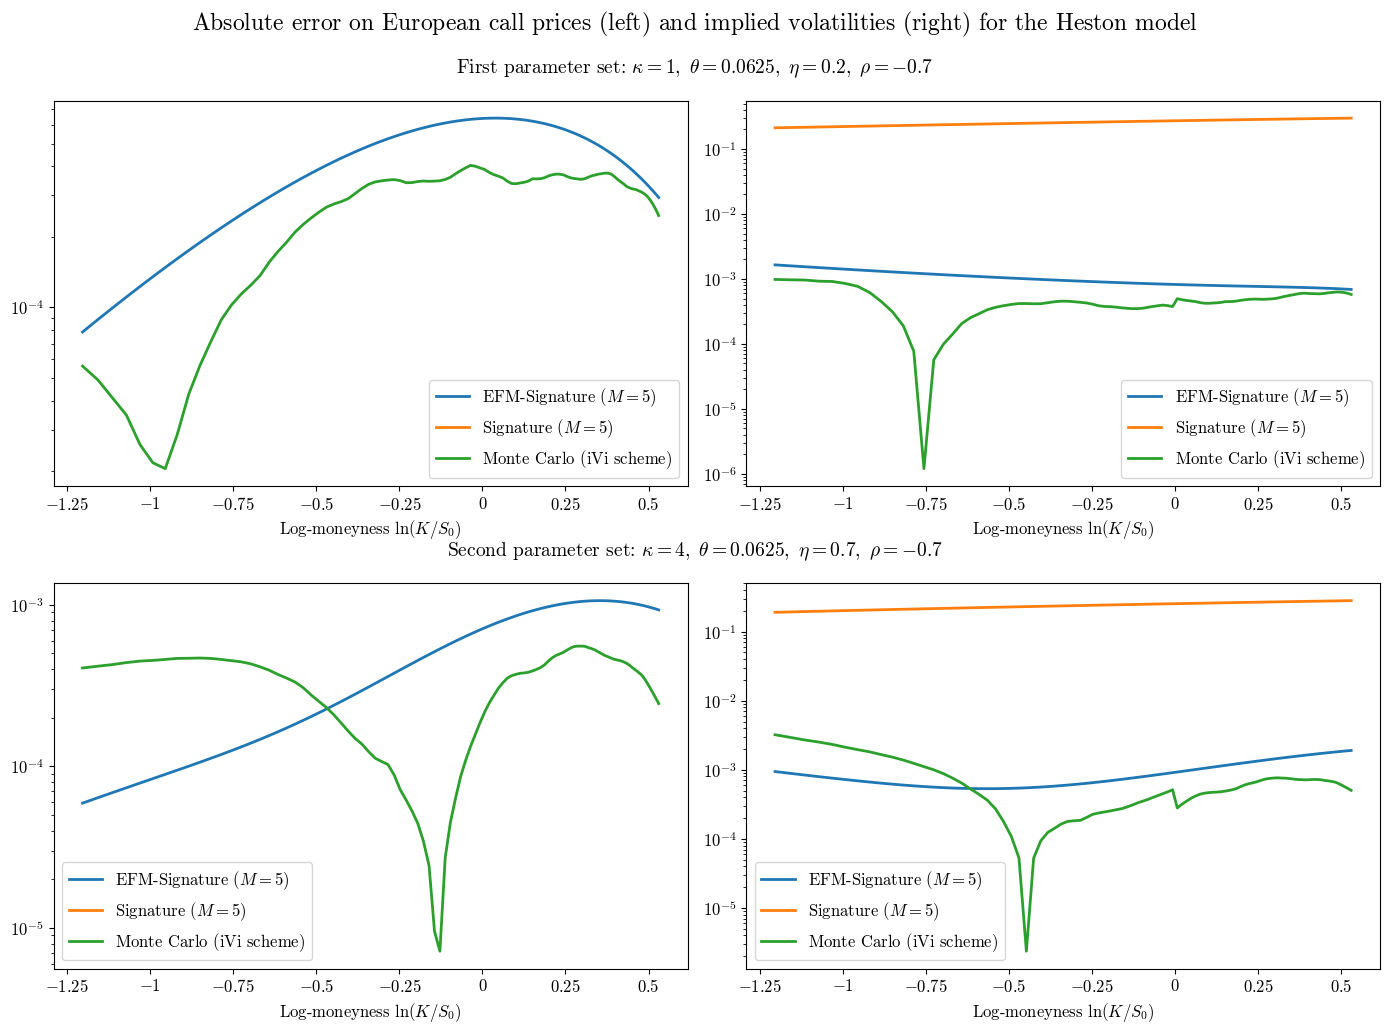

In [246]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))
ax = ax.flatten() 

ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_EFM_1)), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_sig_1)), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[0].semilogy(logmoneyness, np.abs(np.array(prices_closed_1) - np.array(prices_MC_1)), lw=2, label=r"$\text{Monte Carlo (iVi scheme)}$")

ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_EFM_1), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_sig_1), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[1].semilogy(logmoneyness, np.abs(iv_closed_1 - iv_MC_1), lw=2, label=r"$\text{Monte Carlo (iVi scheme)}$")

ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_EFM_2)), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_sig_2)), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[2].semilogy(logmoneyness, np.abs(np.array(prices_closed_2) - np.array(prices_MC_2)), lw=2, label=r"$\text{Monte Carlo (iVi scheme)}$")

ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_EFM_2), lw=2, label=r"$\text{EFM-Signature }$" + fr"$(M={M})$")
ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_sig_2), lw=2, label=r"$\text{Signature }$" + fr"$(M={M})$")
ax[3].semilogy(logmoneyness, np.abs(iv_closed_2 - iv_MC_2), lw=2, label=r"$\text{Monte Carlo (iVi scheme)}$")

for i in range(4) : 
    ax[i].legend(loc="best", fontsize=12)
    ax[i].set_xlabel(r"$\text{Log-moneyness }\ln(K/S_0)$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$"))
    ax[i].tick_params(axis='both', labelsize=12) 

fig.suptitle(r"$\text{Absolute error on European call prices (left) and implied volatilities (right) for the Heston model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \kappa={kappa_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \kappa={kappa_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

### II.3. $q$-Volatility swaps

In [247]:
U_max = 100
q = 0.5
L = 100
u, w =  gauss_legendre_interval(L, np.sqrt(U_max))
u_grid = jnp.array([0.0])

_, sigma_1, sigma_2_1, projectors_1, tuples_1 = offline_procedure(np.asarray(l_1.array)[1:], x_1, M, L, n=252)
_, sigma_2, sigma_2_2, projectors_2, tuples_2 = offline_procedure(np.asarray(l_2.array)[1:], x_2, M, L, n=252)

In [252]:
T_values = np.linspace(1/52, T, 50)

W0_1 = EFM_sig_1[:, 0, 0]
W0_2 = EFM_sig_2[:, 0, 0]

In [253]:
values_EFM_vol_1, values_EFM_var_1 = [], []
values_sig_vol_1, values_sig_var_1 = [], []

values_EFM_vol_2, values_EFM_var_2 = [], []
values_sig_vol_2, values_sig_var_2 = [], []

E_lambd_1 = expected_bm_EFM_signature(M, lambd_1) 
E_lambd_2 = expected_bm_EFM_signature(M, lambd_2) 

l_EFM_sq_1 = shuffle_pow(l_EFM_1, p=2, shuffle_table=shuffle_table)
l_EFM_sq_2 = shuffle_pow(l_EFM_2, p=2, shuffle_table=shuffle_table)

l_sq_1 = shuffle_pow(l_1, p=2, shuffle_table=shuffle_table)
l_sq_1_1 = tensor_prod_word(l_sq_1, word=1)

l_sq_2 = shuffle_pow(l_2, p=2, shuffle_table=shuffle_table)
l_sq_1_2 = tensor_prod_word(l_sq_2, word=1)

for T in tqdm(T_values) : 
    v_grid = jnp.array(-u**2/T)
    t_main_T = jnp.linspace(0.0, T, max(int(T * 365 * 5), 500) + 1)
    psi_EFM_1 = solve_Riccati_EFM_vol(u_grid, v_grid, l_EFM_1, lambd_1, rho_1, shuffle_table, t_main_T, M, d).real
    psi_EFM_2 = solve_Riccati_EFM_vol(u_grid, v_grid, l_EFM_2, lambd_2, rho_2, shuffle_table, t_main_T, M, d).real
    
    values_EFM_vol_1.append(float(compute_vol_swap_EFM_sig(u, w, psi_EFM_1, W0_1, U_max, q=0.5)))
    values_EFM_vol_2.append(float(compute_vol_swap_EFM_sig(u, w, psi_EFM_2, W0_2, U_max, q=0.5)))
    
    values_EFM_var_1.append(compute_variance_swap_EFM_sig(EFM_sig_1, t_main_T, lambd_1, M, l_EFM_sq_1)) 
    values_EFM_var_2.append(compute_variance_swap_EFM_sig(EFM_sig_2, t_main_T, lambd_2, M, l_EFM_sq_2)) 
    
    psi_1 = compute_psi_vol_swap(T, rho_1, u**2, sigma_1, sigma_2_1, projectors_1, tuples_1)
    psi_2 = compute_psi_vol_swap(T, rho_2, u**2, sigma_2, sigma_2_2, projectors_2, tuples_2)

    values_sig_vol_1.append(compute_vol_swap(u, w, psi_1, U_max))
    values_sig_vol_2.append(compute_vol_swap(u, w, psi_2, U_max))
    
    E = Tensor(array=expected_bm_signature(t=T, M=M)[:, 0], M=M, d=d)
    bracket_1 = float(l_sq_1_1 @ E)
    bracket_2 = float(l_sq_1_2 @ E)
    values_sig_var_1.append(1/T * bracket_1)
    values_sig_var_2.append(1/T * bracket_2)

100%|███████████████████████████████████████████| 50/50 [23:02<00:00, 27.65s/it]


In [254]:
N_mc, n_mc = 200000, 252
Z = simulate_antithetic(N_mc, n_mc, d=1)[:, :, 0]
eta_ = np.random.uniform(size=(N_mc, n_mc)) 

values_mc_vol_1, values_mc_lower_vol_1, values_mc_upper_vol_1 = [], [], []
values_mc_var_1, values_mc_lower_var_1, values_mc_upper_var_1 = [], [], []

values_mc_vol_2, values_mc_lower_vol_2, values_mc_upper_vol_2 = [], [], []
values_mc_var_2, values_mc_lower_var_2, values_mc_upper_var_2 = [], [], []


for i, T in enumerate(tqdm(T_values)) : 
    hat_V_1, hat_U_1, hat_Z_1 = simulate_hat_VUZ(V0=x_1, T=T, a=kappa_1*theta_1, b=-kappa_1, c=eta_1, N=Z, eta=eta_) # iVi scheme
    U_1, Z_1 = get_UZ_trajectories(hat_U_1, hat_Z_1) 
    V_T_1 = U_1[:, -1]

    hat_V_2, hat_U_2, hat_Z_2 = simulate_hat_VUZ(V0=x_2, T=T, a=kappa_2*theta_2, b=-kappa_2, c=eta_2, N=Z, eta=eta_) # iVi scheme
    U_2, Z_2 = get_UZ_trajectories(hat_U_2, hat_Z_2) 
    V_T_2 = U_2[:, -1]
    
    sample_1 = np.sqrt(V_T_1 / T)
    mid, _, lower, upper = monte_carlo(sample_1) 
    values_mc_vol_1.append(mid); values_mc_lower_vol_1.append(lower); values_mc_upper_vol_1.append(upper)
    sample_2 = np.sqrt(V_T_2 / T)
    mid, _, lower, upper = monte_carlo(sample_2) 
    values_mc_vol_2.append(mid); values_mc_lower_vol_2.append(lower); values_mc_upper_vol_2.append(upper)

    sample_1 = V_T_1 / T
    mid, _, lower, upper = monte_carlo(sample_1) 
    values_mc_var_1.append(mid); values_mc_lower_var_1.append(lower); values_mc_upper_var_1.append(upper)
    sample_2 = V_T_2 / T
    mid, _, lower, upper = monte_carlo(sample_2) 
    values_mc_var_2.append(mid); values_mc_lower_var_2.append(lower); values_mc_upper_var_2.append(upper)

100%|███████████████████████████████████████████| 50/50 [00:34<00:00,  1.45it/s]


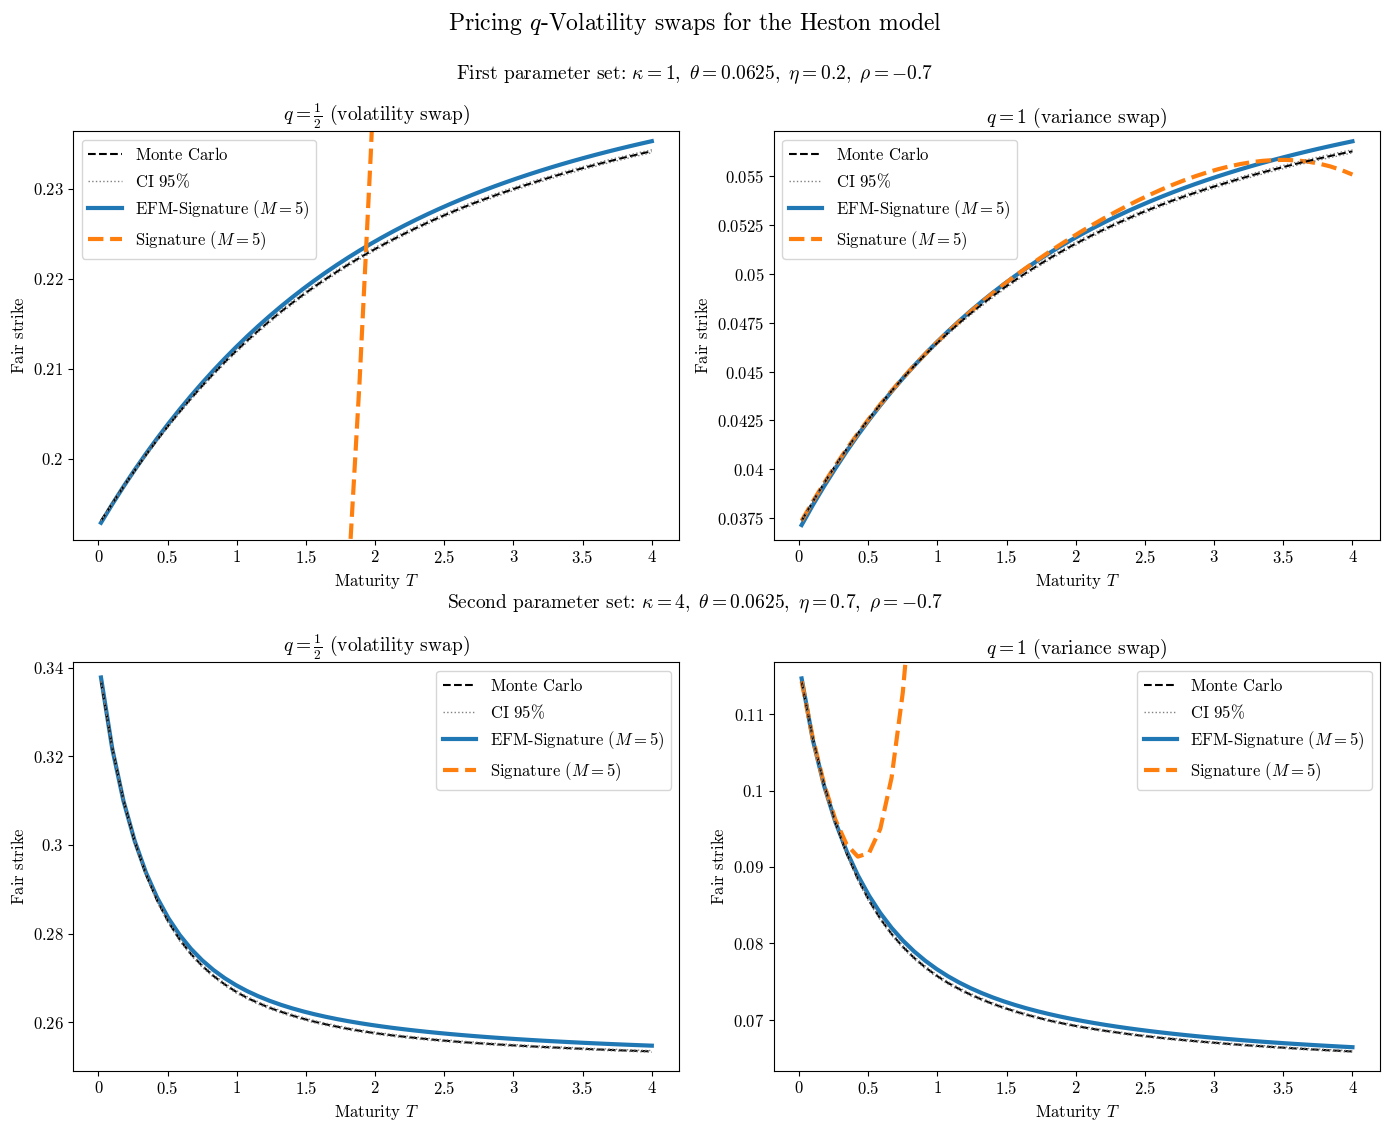

In [257]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11.5))
ax = ax.flatten() 

ax[0].plot(T_values, values_mc_vol_1, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[0].plot(T_values, values_mc_lower_vol_1, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[0].plot(T_values, values_mc_upper_vol_1, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[0].get_ylim() 
ax[0].plot(T_values, values_EFM_vol_1, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[0].plot(T_values, values_sig_vol_1, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[0].set_ylim(lims)

ax[1].plot(T_values, values_mc_var_1, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[1].plot(T_values, values_mc_lower_var_1, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[1].plot(T_values, values_mc_upper_var_1, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[1].get_ylim() 
ax[1].plot(T_values, values_EFM_var_1, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[1].plot(T_values, values_sig_var_1, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[1].set_ylim(lims)

ax[2].plot(T_values, values_mc_vol_2, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[2].plot(T_values, values_mc_lower_vol_2, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[2].plot(T_values, values_mc_upper_vol_2, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[2].get_ylim() 
ax[2].plot(T_values, values_EFM_vol_2, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[2].plot(T_values, values_sig_vol_2, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[2].set_ylim(lims)

ax[3].plot(T_values, values_mc_var_2, label = r"$\text{Monte Carlo}$", color = "black", linestyle ="--", zorder=1)
ax[3].plot(T_values, values_mc_lower_var_2, label = r"$\text{CI } 95\%$", color = "gray", linestyle =":", lw=1, zorder=1)
ax[3].plot(T_values, values_mc_upper_var_2, color = "gray", linestyle =":", lw = 1, zorder=1)
lims = ax[3].get_ylim() 
ax[3].plot(T_values, values_EFM_var_2, label = r"$\text{EFM-Signature }$" + fr"$(M={M})$", color = "tab:blue", linewidth=3, zorder=0)
ax[3].plot(T_values, values_sig_var_2, label = r"$\text{Signature }$" + fr"$(M={M})$", color = "tab:orange", linestyle="--", linewidth=3, zorder=0)
ax[3].set_ylim(lims)

ax[0].set_title(r"$q =\frac{1}{2} \text{ (volatility swap)}$", fontsize=14)
ax[2].set_title(r"$q =\frac{1}{2} \text{ (volatility swap)}$", fontsize=14)
ax[1].set_title(r"$q =1 \text{ (variance swap)}$", fontsize=14)
ax[3].set_title(r"$q =1 \text{ (variance swap)}$", fontsize=14)

for i in range(4) :
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_xlabel(r"$\text{Maturity } T$", fontsize=12)
    ax[i].set_ylabel(r"$\text{Fair strike}$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Pricing }q\text{-Volatility swaps for the Heston model}$", fontsize=17)

fig.text(0.5, 0.92, fr"$\text{{First parameter set: }} \kappa={kappa_1},\ \theta={theta_1},\ \eta={eta_1},\ \rho={rho_1}$", ha="center", fontsize=14)
fig.text(0.5, 0.46, fr"$\text{{Second parameter set: }} \kappa={kappa_2},\ \theta={theta_2},\ \eta={eta_2},\ \rho={rho_2}$", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.savefig("vol_swaps_Heston_EFM.png", dpi=300, transparent=True)
plt.show()